# Diabetes: Case Study

### Dataset installation

In [1]:
# !curl -L -o ./diabetes-health-indicators-dataset.zip https://www.kaggle.com/api/v1/datasets/download/alexteboul/diabetes-health-indicators-dataset

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0

  0      0   0      0   0      0      0      0                              0
 34  6.03M  34  2.10M   0      0  1.77M      0   00:03   00:01   00:02  2.10M
100  6.03M 100  6.03M   0      0  4.45M      0   00:01   00:01          2.10M
100  6.03M 100  6.03M   0      0  4.45M      0   00:01   00:01          2.10M
100  6.03M 100  6.03M   0      0  4.45M      0   00:01   00:01          2.10M


### Import packages

In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, make_scorer
from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.metrics import geometric_mean_score
from xgboost import XGBClassifier
from scipy.stats import ttest_ind, chi2_contingency, f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from mpl_toolkits.mplot3d import Axes3D
import warnings
warnings.filterwarnings('ignore')

### General information

In [3]:
df = pd.read_csv("./diabetes-health-indicators-dataset/diabetes_012_health_indicators_BRFSS2015.csv")

In [4]:
rows , col =  df.shape
print(f"Number of Rows : {rows} \nNumber of Columns : {col}")

Number of Rows : 253680 
Number of Columns : 22


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [6]:
df.isna().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

### Data visualization

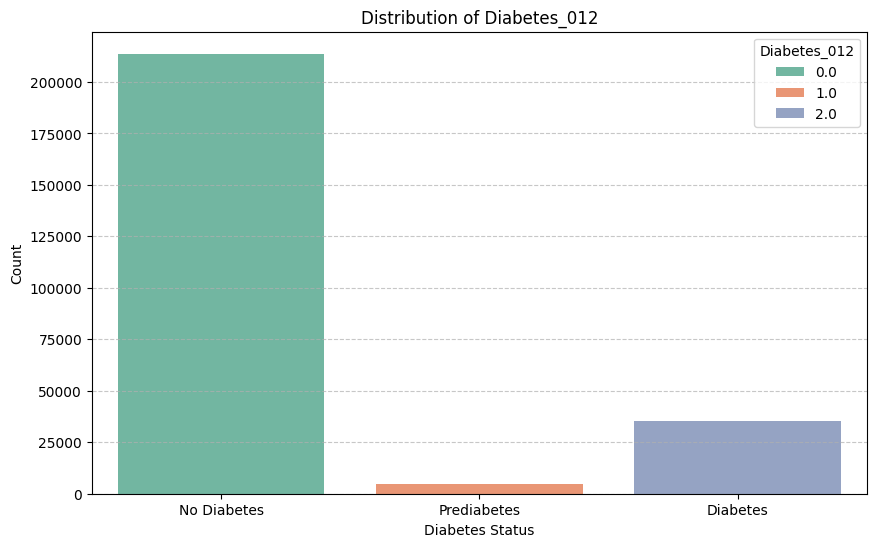

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(x="Diabetes_012", data=df, hue="Diabetes_012", palette="Set2")
plt.title("Distribution of Diabetes_012")
plt.xticks([0, 1, 2], ["No Diabetes", "Prediabetes", "Diabetes"])
plt.xlabel("Diabetes Status")
plt.ylabel("Count")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

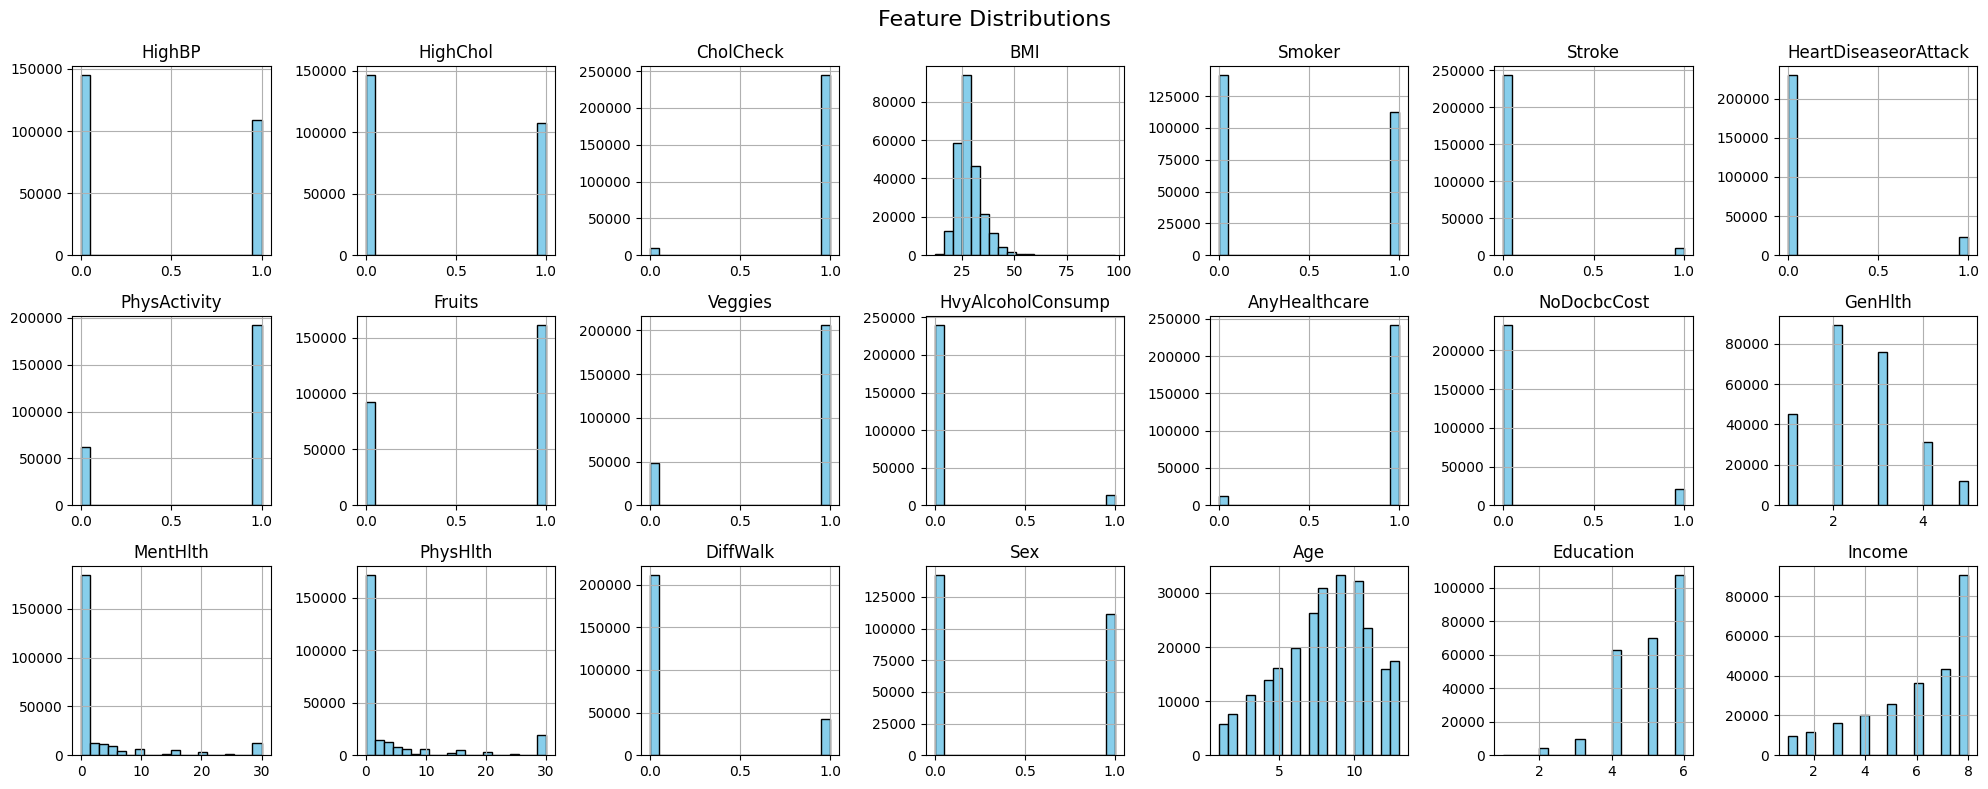

In [8]:
df.drop(['Diabetes_012'], axis=1).hist(figsize=(20, 8), layout=(3, 7), bins=20, color="skyblue", edgecolor="black")
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.show()

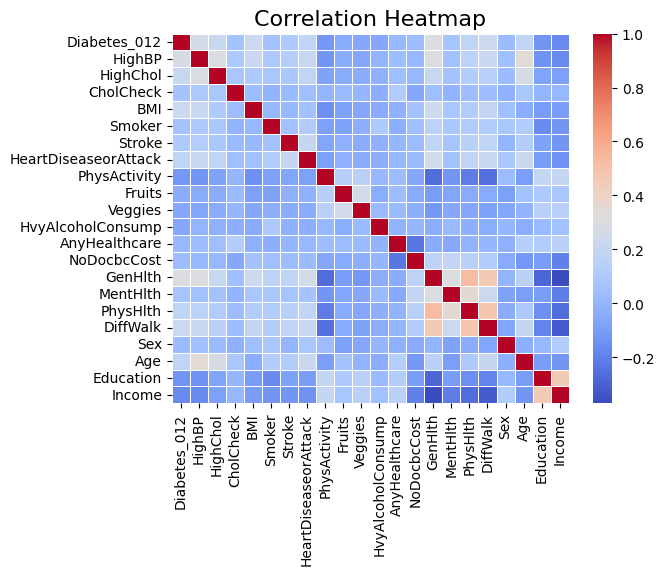

In [10]:
plt.Figure(figsize=(20, 20))
sns.heatmap(df.corr(), annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap", fontsize=16)
plt.show()

In [16]:
df_no_diabetes = df[df["Diabetes_012"] == 0]
df_prediabetes = df[df["Diabetes_012"] == 1]
df_diabetes = df[df["Diabetes_012"] == 2]

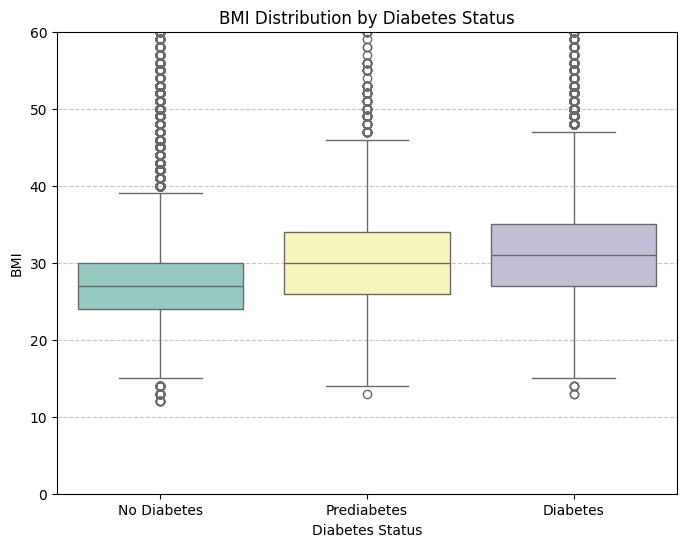

In [19]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Diabetes_012", y="BMI", data=df, palette="Set3")
plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("Diabetes Status")
plt.ylabel("BMI")
plt.xticks([0, 1, 2], ["No Diabetes", "Prediabetes", "Diabetes"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.ylim(0, 60)
plt.show()

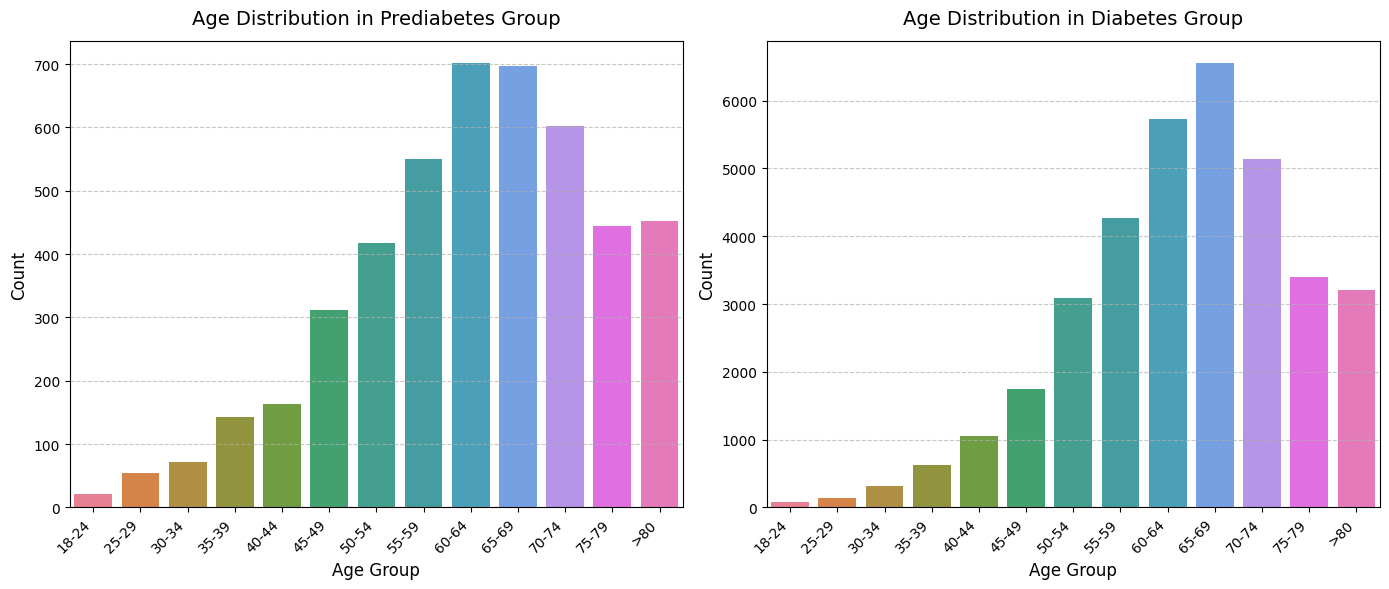

In [27]:
age_labels = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', 
              '50-54', '55-59', '60-64', '65-69', '70-74', '75-79', '>80']

fig, ax = plt.subplots(1, 2, figsize=(14, 6), sharey=False)

sns.countplot(x="Age", data=df_prediabetes, ax=ax[0], palette="husl")
ax[0].set_title("Age Distribution in Prediabetes Group", fontsize=14, pad=12)
ax[0].set_xlabel("Age Group", fontsize=12)
ax[0].set_ylabel("Count", fontsize=12)
ax[0].set_xticks(range(len(age_labels)))
ax[0].set_xticklabels(age_labels, rotation=45, ha='right')
ax[0].grid(axis="y", linestyle="--", alpha=0.7)

sns.countplot(x="Age", data=df_diabetes, ax=ax[1], palette="husl")
ax[1].set_title("Age Distribution in Diabetes Group", fontsize=14, pad=12)
ax[1].set_xlabel("Age Group", fontsize=12)
ax[1].set_ylabel("Count", fontsize=12)
ax[1].set_xticks(range(len(age_labels)))
ax[1].set_xticklabels(age_labels, rotation=45, ha='right')
ax[1].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

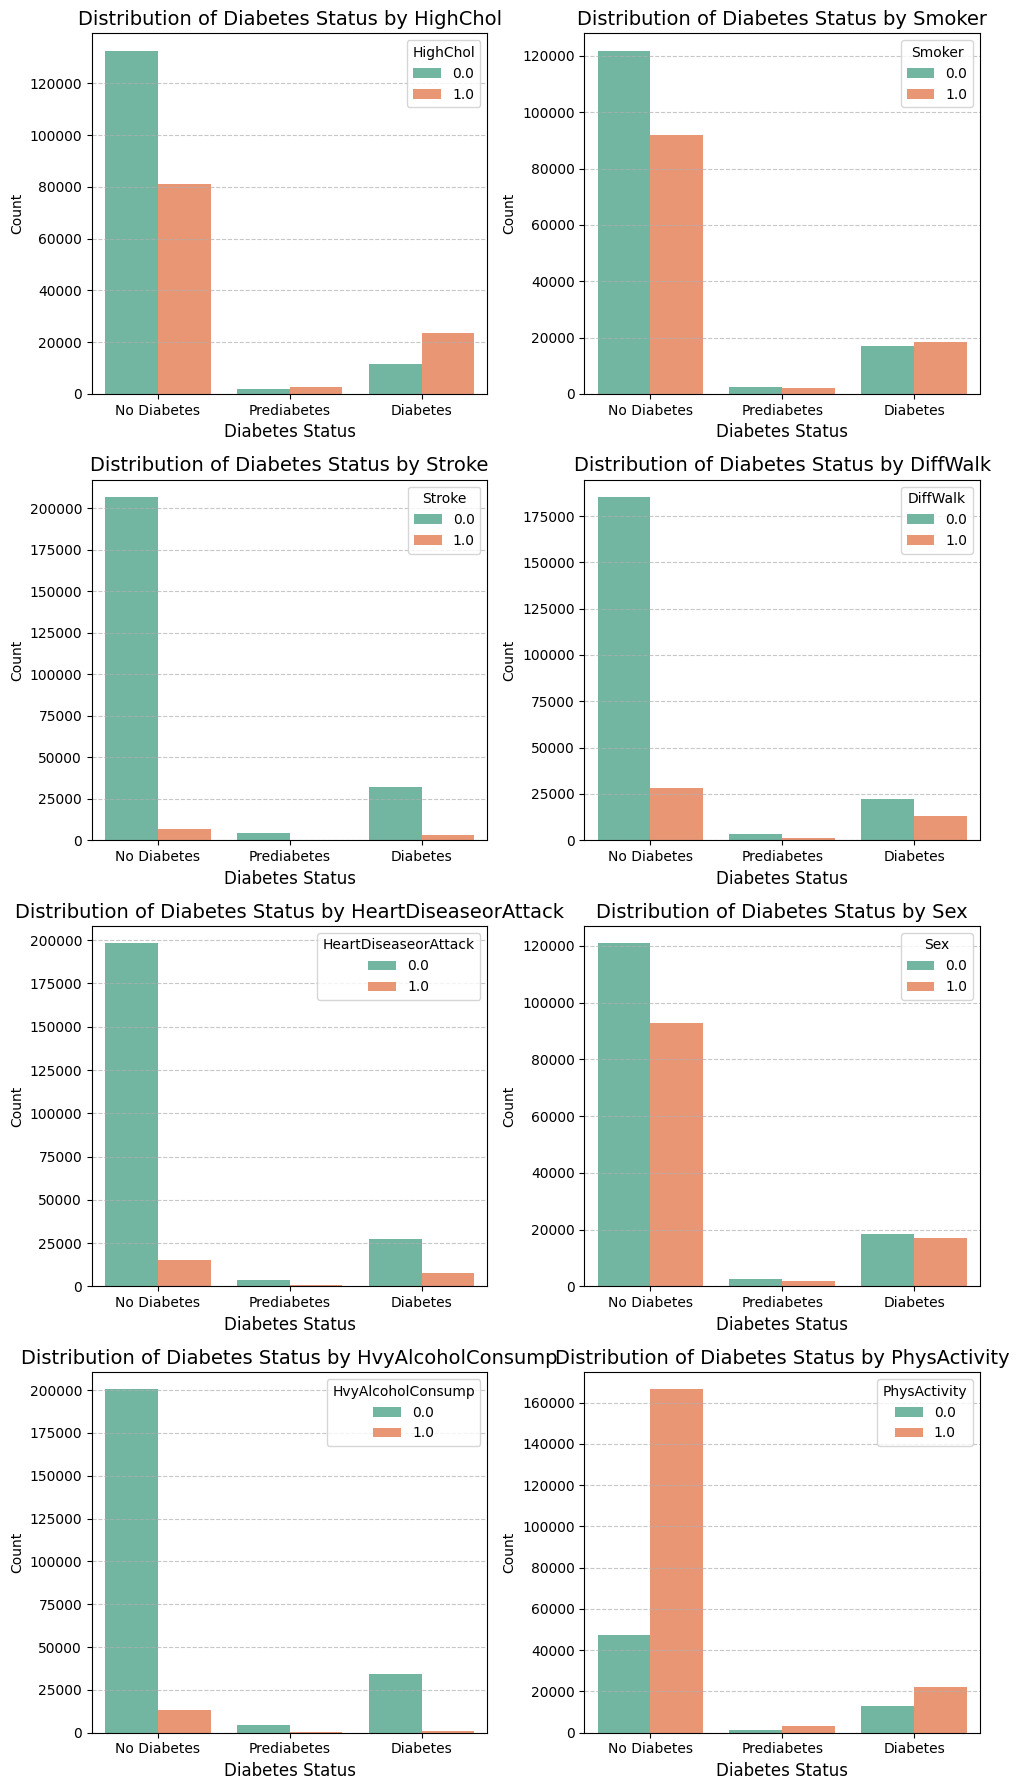

In [61]:
columns = ['HighChol', 'Smoker', 'Stroke', 'DiffWalk', 'HeartDiseaseorAttack', 'Sex', 'HvyAlcoholConsump', 'PhysActivity']

plt.figure(figsize=(10, 18))
for i, col in enumerate(columns):
    plt.subplot(4, 2, i+1)
    sns.countplot(x="Diabetes_012", hue=col, data=df, palette="Set2")
    plt.title(f"Distribution of Diabetes Status by {col}", fontsize=14)
    plt.xlabel("Diabetes Status", fontsize=12)
    plt.xticks([0, 1, 2], ["No Diabetes", "Prediabetes", "Diabetes"])
    plt.ylabel("Count")
    plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()

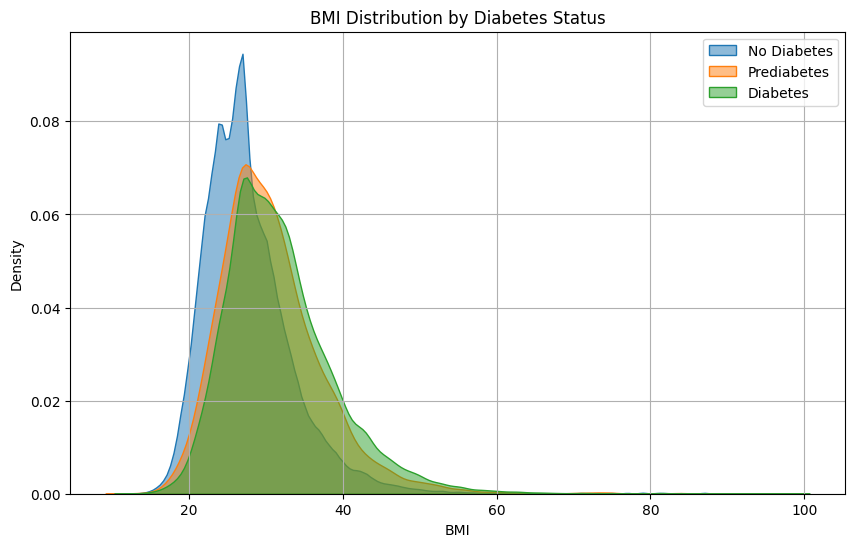

In [34]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df_no_diabetes["BMI"], label="No Diabetes", fill=True, alpha=0.5)
sns.kdeplot(df_prediabetes["BMI"], label="Prediabetes", fill=True, alpha=0.5)
sns.kdeplot(df_diabetes["BMI"], label="Diabetes", fill=True, alpha=0.5)
plt.title("BMI Distribution by Diabetes Status")
plt.xlabel("BMI")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

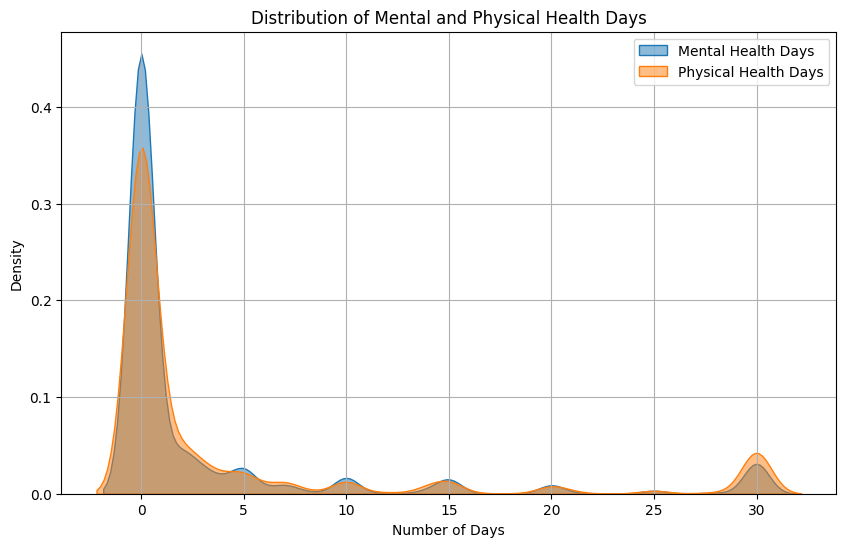

In [66]:
plt.figure(figsize=(10, 6))
sns.kdeplot(df['MentHlth'], fill=True, alpha=0.5)
sns.kdeplot(df['PhysHlth'], fill=True, alpha=0.5)
plt.title("Distribution of Mental and Physical Health Days")
plt.xlabel("Number of Days")
plt.ylabel("Density")
plt.legend(["Mental Health Days", "Physical Health Days"])
plt.grid()
plt.show()

### Hypothesis testing

In [49]:
alpha = 0.05

$\mathcal{H}_0: \mu_0^\mathrm{BMI} = \mu_1^\mathrm{BMI} = \mu_2^\mathrm{BMI} \\ \mathcal{H}_1: \lnot \mathcal{H}_0$ 

In [64]:
f_stat, anova_p = f_oneway(df_no_diabetes['BMI'], df_prediabetes['BMI'], df_diabetes['BMI'])

print(f"ANOVA F-Statistic: {f_stat:.4f}")
print(f"ANOVA p-value:     {anova_p:.4e}")
print("\n" + "="*50 + "\n")

if anova_p < alpha:
    print("ANOVA is significant! Running Tukey HSD to find the pairs...\n")
    
    tukey = pairwise_tukeyhsd(endog=df['BMI'],           
                              groups=df['Diabetes_012'], 
                              alpha=alpha)               
    print(tukey)
else:
    print("No significant differences found across any groups.")

ANOVA F-Statistic: 6768.3611
ANOVA p-value:     0.0000e+00


ANOVA is significant! Running Tukey HSD to find the pairs...

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj lower  upper  reject
-------------------------------------------------
   0.0    1.0   2.9819   0.0 2.7578 3.2061   True
   0.0    2.0   4.2015   0.0 4.1148 4.2881   True
   1.0    2.0   1.2195   0.0 0.9837 1.4554   True
-------------------------------------------------


In [65]:
mean_predia = df_prediabetes["BMI"].mean()
mean_dia = df_diabetes["BMI"].mean()

print(f"Mean BMI (Prediabetes): {mean_predia:.2f}")
print(f"Mean BMI (Diabetes):    {mean_dia:.2f}")
print(f"Absolute Difference:    {abs(mean_predia - mean_dia):.2f} BMI units\n")

n1, n2 = len(df_prediabetes), len(df_diabetes)
var1, var2 = df_prediabetes["BMI"].var(), df_diabetes["BMI"].var()
pooled_std = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

cohens_d = (mean_predia - mean_dia) / pooled_std
print(f"Cohen's d Effect Size:  {abs(cohens_d):.4f}")

Mean BMI (Prediabetes): 30.72
Mean BMI (Diabetes):    31.94
Absolute Difference:    1.22 BMI units

Cohen's d Effect Size:  0.1666


$\mathcal{H}_0: \text{Mental health and Physical health have statistically insignificant association} \\ \mathcal{H}_1: \lnot \mathcal{H}_0$ 

In [67]:
contingency_table = pd.crosstab(df['MentHlth'], df['PhysHlth'])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Squared Test: chi2={chi2:.4f}, p-value={p_value:.4f}, dof={dof}")

if p_value < alpha:
    print("Reject null hypothesis: Significant association between Mental and Physical Health Days")
else:
    print("Fail to reject null hypothesis: No significant association between Mental and Physical Health Days")

Chi-Squared Test: chi2=76812.9704, p-value=0.0000, dof=900
Reject null hypothesis: Significant association between Mental and Physical Health Days


$\mathcal{H}_0: \mu^\mathrm{MentHlth} = \mu^\mathrm{PhysHlth} \\ \mathcal{H}_1: \lnot \mathcal{H}_0$ 

In [68]:
_, p_value = ttest_ind(df_no_diabetes['MentHlth'], df_diabetes['PhysHlth'])
if p_value < alpha: 
    print("Reject null hypothesis: Significant difference in Mental Health Days between No Diabetes and Diabetes groups")
else:
    print("Fail to reject null hypothesis: No significant difference in Mental Health Days between No Diabetes and Diabetes groups")

Reject null hypothesis: Significant difference in Mental Health Days between No Diabetes and Diabetes groups


$\mathcal{H}_0: \text{Heavy alcohol consumption and Diabetes Status have statistically insignificant association} \\ \mathcal{H}_1: \lnot \mathcal{H}_0$ 

In [56]:
contingency_table = pd.crosstab(df['HvyAlcoholConsump'], df['Diabetes_012'])

normalized_table = pd.crosstab(df['HvyAlcoholConsump'], df['Diabetes_012'], normalize='index') * 100

print("--- Actual Proportions (%) Per Group ---")
print(normalized_table.round(2))
print("\n" + "="*40 + "\n")

chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square p-value: {p_value:.4e}")

if p_value < alpha:
    print("Reject null hypothesis: Significant association between Heavy Alcohol Consumption and Diabetes Status")
else:
    print("Fail to reject null hypothesis: No significant association between Heavy Alcohol Consumption and Diabetes Status")

--- Actual Proportions (%) Per Group ---
Diabetes_012         0.0   1.0    2.0
HvyAlcoholConsump                    
0.0                83.74  1.85  14.42
1.0                92.70  1.46   5.84


Chi-Square p-value: 2.2619e-185
Reject null hypothesis: Significant association between Heavy Alcohol Consumption and Diabetes Status


In [57]:
print(df.groupby('HvyAlcoholConsump')['Age'].mean())

HvyAlcoholConsump
0.0    8.057889
1.0    7.599327
Name: Age, dtype: float64


In [58]:
print(df.groupby('HvyAlcoholConsump')['BMI'].mean())

HvyAlcoholConsump
0.0    28.460956
1.0    27.062430
Name: BMI, dtype: float64


$\mathcal{H}_0: \text{Physical activity and Diabetes Status have statistically insignificant association} \\ \mathcal{H}_1: \lnot \mathcal{H}_0$ 

In [62]:
contingency_table = pd.crosstab(df['PhysActivity'], df['Diabetes_012'])

normalized_table = pd.crosstab(df['PhysActivity'], df['Diabetes_012'], normalize='index') * 100
print("--- Actual Proportions (%) Per Group ---")
print(normalized_table.round(2))
print("\n" + "="*40 + "\n")
chi2, p_value, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-Square p-value: {p_value:.4e}")

if p_value < alpha:
    print("Reject null hypothesis: Significant association between Physical Activity and Diabetes Status")
else:
    print("Fail to reject null hypothesis: No significant association between Physical Activity and Diabetes Status")

--- Actual Proportions (%) Per Group ---
Diabetes_012    0.0   1.0    2.0
PhysActivity                    
0.0           76.44  2.41  21.14
1.0           86.75  1.64  11.61


Chi-Square p-value: 0.0000e+00
Reject null hypothesis: Significant association between Physical Activity and Diabetes Status


### Data Visualiation

In [11]:
X = df.drop("Diabetes_012", axis=1)
y = df["Diabetes_012"]

pca = PCA(n_components=2)
X_red = pca.fit_transform(X)

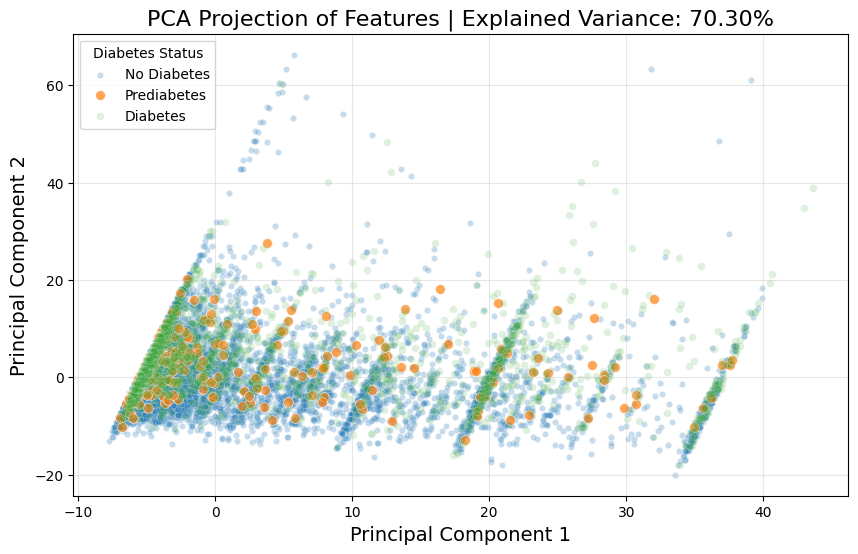

In [12]:
_, X_sample, _, y_sample = train_test_split(
    X_red, y, test_size=15000, stratify=y
)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_sample[:, 0][y_sample == 0], y=X_sample[:, 1][y_sample == 0], s=20, alpha=0.25)
sns.scatterplot(x=X_sample[:, 0][y_sample == 1], y=X_sample[:, 1][y_sample == 1], s=50, alpha=0.7)
sns.scatterplot(x=X_sample[:, 0][y_sample == 2], y=X_sample[:, 1][y_sample == 2], s=30, alpha=0.15) 
plt.title(f"PCA Projection of Features | Explained Variance: {pca.explained_variance_ratio_.sum() * 100:.2f}%", fontsize=16)
plt.xlabel("Principal Component 1", fontsize=14)
plt.ylabel("Principal Component 2", fontsize=14)
plt.legend(title="Diabetes Status", labels=["No Diabetes", "Prediabetes", "Diabetes"])
plt.grid(alpha=0.3)
plt.show()

In [13]:
pca_3d = PCA(n_components=3)
X_red_3d = pca_3d.fit_transform(X)

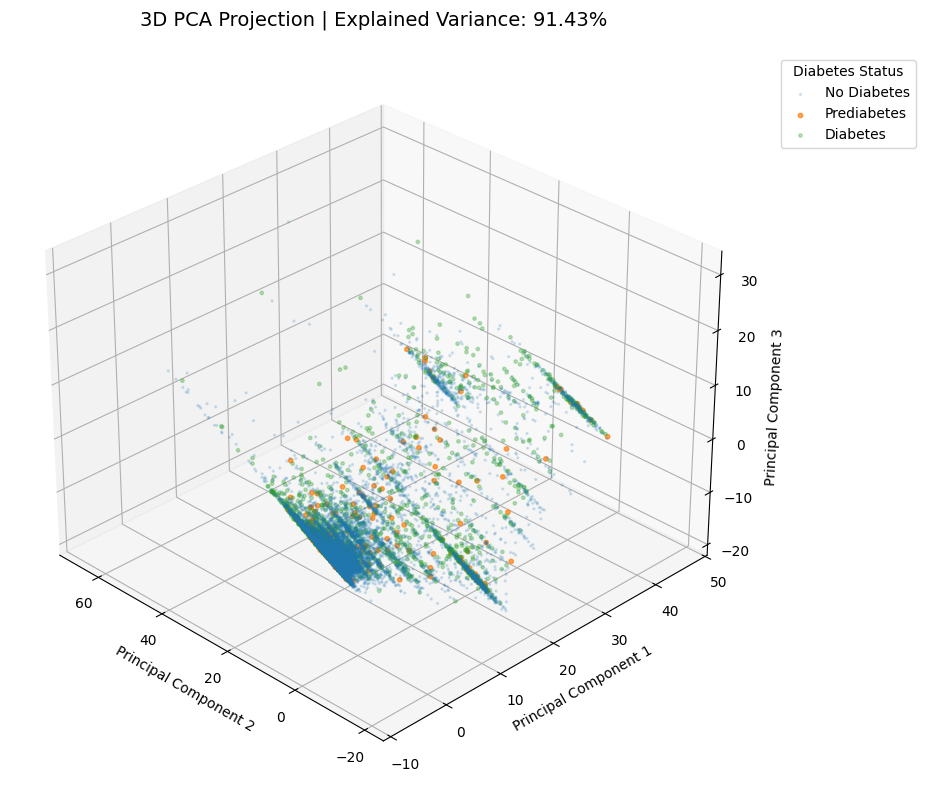

In [14]:
_, X_sample, _, y_sample = train_test_split(
    X_red_3d, y, test_size=15000, stratify=y
)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X_sample[:, 0][y_sample == 0], X_sample[:, 1][y_sample == 0], X_sample[:, 2][y_sample == 0], s=2, alpha=0.15, label="No Diabetes")

ax.scatter(X_sample[:, 0][y_sample == 1], X_sample[:, 1][y_sample == 1], X_sample[:, 2][y_sample == 1], s=10, alpha=0.7, label="Prediabetes")

ax.scatter(X_sample[:, 0][y_sample == 2], X_sample[:, 1][y_sample == 2], X_sample[:, 2][y_sample == 2], s=6, alpha=0.3, label="Diabetes")

ax.set_title(f"3D PCA Projection | Explained Variance: {pca_3d.explained_variance_ratio_.sum() * 100:.2f}%", fontsize=14, pad=20)
ax.set_xlabel("Principal Component 1", fontsize=10)
ax.set_ylabel("Principal Component 2", fontsize=10)
ax.set_zlabel("Principal Component 3", fontsize=10)

ax.legend(title="Diabetes Status", loc="upper left", bbox_to_anchor=(1.05, 1))
ax.grid(alpha=0.2)

ax.view_init(azim=-135)
ax.zaxis._axinfo['juggled'] = (1, 2, 2)

plt.subplots_adjust(left=0.18, right=0.82)
plt.tight_layout()
plt.show()

### Feature selection

In [80]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)
xgb_baseline = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb_baseline.fit(X_train, y_train)

selection = SelectFromModel(xgb_baseline, threshold="0.5*mean", prefit=True)

X_train_selected = selection.transform(X_train)
X_test_selected = selection.transform(X_test)

selected_features = X.columns[selection.get_support()]
print("Features kept:", list(selected_features))
print(f"Reduced feature count from {X.shape[1]} down to {X_train_selected.shape[1]}")

Features kept: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'HeartDiseaseorAttack', 'HvyAlcoholConsump', 'GenHlth', 'Age']
Reduced feature count from 21 down to 8


### Model training

In [96]:
models = [XGBClassifier, LogisticRegression, RandomForestClassifier, LinearSVC]
base_params = {
    "XGBClassifier": { "eval_metric": "mlogloss", "n_jobs": -1, "random_state": 42 },
    "LogisticRegression": { "class_weight": "balanced", "n_jobs": -1, "random_state": 42, "max_iter": 1000 },
    "RandomForestClassifier": { "class_weight": "balanced", "n_jobs": -1, "random_state": 42 },
    "LinearSVC": { "class_weight": "balanced", "random_state": 42, "dual": False }
}

search_spaces = {
    "XGBClassifier": { "model__n_estimators": [100, 200], "model__max_depth": [3, 5], "model__learning_rate": [0.01, 0.1] },
    "LogisticRegression": { "model__C": [0.01, 0.1, 1, 10], "model__penalty": ["l1", "l2"], "model__solver": ["saga"] },
    "RandomForestClassifier": { "model__n_estimators": [100, 200], "model__max_depth": [None, 10, 20] },
    "LinearSVC": { "model__estimator__C": [0.1, 1, 10] }
}

scalers = [StandardScaler(), RobustScaler()]
all_features = [True, False]
tune_hp = [True, False]
class_imbalance_strategies = [None, SMOTE(random_state=42), RandomOverSampler(random_state=42), RandomUnderSampler(random_state=42)]

scoring_metrics = {
    "ROC_AUC": "roc_auc_ovr",
    "F1_Score": "f1_weighted",
    "Accuracy": "accuracy",
    "G_Mean": make_scorer(geometric_mean_score, average='weighted')
}

results_list = []

for model in models:
    model_name = model.__name__
    print(f"\n--- Processing {model_name} ---")
    
    param_grid = search_spaces[model_name]
    base_args = base_params[model_name]
    
    for tune in tune_hp:
        for scaler in scalers:
            for use_all_features in all_features:
                X_tr = X_train if use_all_features else X_train_selected
                X_te = X_test if use_all_features else X_test_selected
                
                for imbalance_strategy in class_imbalance_strategies:
                    pipeline_steps = []
                    if imbalance_strategy is not None:
                        pipeline_steps.append(('imbalance', imbalance_strategy))
                    pipeline_steps.append(('scaler', scaler))

                    raw_model = model(**base_args)

                    if model_name == "LinearSVC":
                        calibrated_model = CalibratedClassifierCV(raw_model, cv=3, n_jobs=-1)
                        pipeline_steps.append(('model', calibrated_model))
                    else:
                        pipeline_steps.append(('model', raw_model))

                    pipeline = ImbPipeline(steps=pipeline_steps)
                    
                    cv_results = {}
                    
                    if tune:
                        search = RandomizedSearchCV(
                            estimator=pipeline,
                            param_distributions=param_grid,
                            n_iter=5,
                            scoring=scoring_metrics,
                            refit="G_Mean", 
                            cv=3,
                            n_jobs=-1,
                            random_state=42
                        )
                        search.fit(X_tr, y_train)
                        best_model = search.best_estimator_
                        
                        idx = search.best_index_
                        cv_results["CV_ROC_AUC"] = search.cv_results_["mean_test_ROC_AUC"][idx]
                        cv_results["CV_F1"] = search.cv_results_["mean_test_F1_Score"][idx]
                        cv_results["CV_Accuracy"] = search.cv_results_["mean_test_Accuracy"][idx]
                        cv_results["CV_G_Mean"] = search.cv_results_["mean_test_G_Mean"][idx]
                        cv_results["CV_ROC_AUC_Var"] = search.cv_results_["std_test_ROC_AUC"][idx] ** 2
                        cv_results["CV_F1_Var"] = search.cv_results_["std_test_F1_Score"][idx] ** 2
                        cv_results["CV_Accuracy_Var"] = search.cv_results_["std_test_Accuracy"][idx] ** 2
                        cv_results["CV_G_Mean_Var"] = search.cv_results_["std_test_G_Mean"][idx] ** 2
                    else:
                        cv_scores = cross_validate(pipeline, X_tr, y_train, cv=3, scoring=scoring_metrics, n_jobs=-1)
                        best_model = pipeline.fit(X_tr, y_train)
                        
                        cv_results["CV_ROC_AUC"] = np.mean(cv_scores["test_ROC_AUC"])
                        cv_results["CV_F1"] = np.mean(cv_scores["test_F1_Score"])
                        cv_results["CV_Accuracy"] = np.mean(cv_scores["test_Accuracy"])
                        cv_results["CV_G_Mean"] = np.mean(cv_scores["test_G_Mean"])
                        cv_results["CV_ROC_AUC_Var"] = np.var(cv_scores["test_ROC_AUC"])
                        cv_results["CV_F1_Var"] = np.var(cv_scores["test_F1_Score"])
                        cv_results["CV_Accuracy_Var"] = np.var(cv_scores["test_Accuracy"])
                        cv_results["CV_G_Mean_Var"] = np.var(cv_scores["test_G_Mean"])
                    
                    y_pred = best_model.predict(X_te)
                    
                    if hasattr(best_model, "predict_proba"):
                        test_proba = best_model.predict_proba(X_te)
                    else:
                        test_proba = best_model.decision_function(X_te)
                        
                    test_roc = roc_auc_score(y_test, test_proba, multi_class='ovr')
                    test_f1 = f1_score(y_test, y_pred, average='weighted')
                    test_acc = accuracy_score(y_test, y_pred)
                    test_gmean = geometric_mean_score(y_test, y_pred, average='weighted')
                    
                    results_list.append({
                        "Model": model_name,
                        "Tuned": tune,
                        "Scaler": scaler.__class__.__name__,
                        "All_Features": use_all_features,
                        "Imbalance_Strategy": imbalance_strategy.__class__.__name__ if imbalance_strategy else "None",
                        "CV_ROC_AUC": cv_results["CV_ROC_AUC"],
                        "CV_F1_Score": cv_results["CV_F1"],
                        "CV_Accuracy": cv_results["CV_Accuracy"],
                        "CV_G_Mean": cv_results["CV_G_Mean"],
                        "CV_ROC_AUC_Var": cv_results["CV_ROC_AUC_Var"],
                        "CV_F1_Var": cv_results["CV_F1_Var"],
                        "CV_Accuracy_Var": cv_results["CV_Accuracy_Var"],
                        "CV_G_Mean_Var": cv_results["CV_G_Mean_Var"],
                        "Test_ROC_AUC": test_roc,
                        "Test_F1_Score": test_f1,
                        "Test_Accuracy": test_acc,
                        "Test_G_Mean": test_gmean
                    })

df_results = pd.DataFrame(results_list)


--- Processing LinearSVC ---


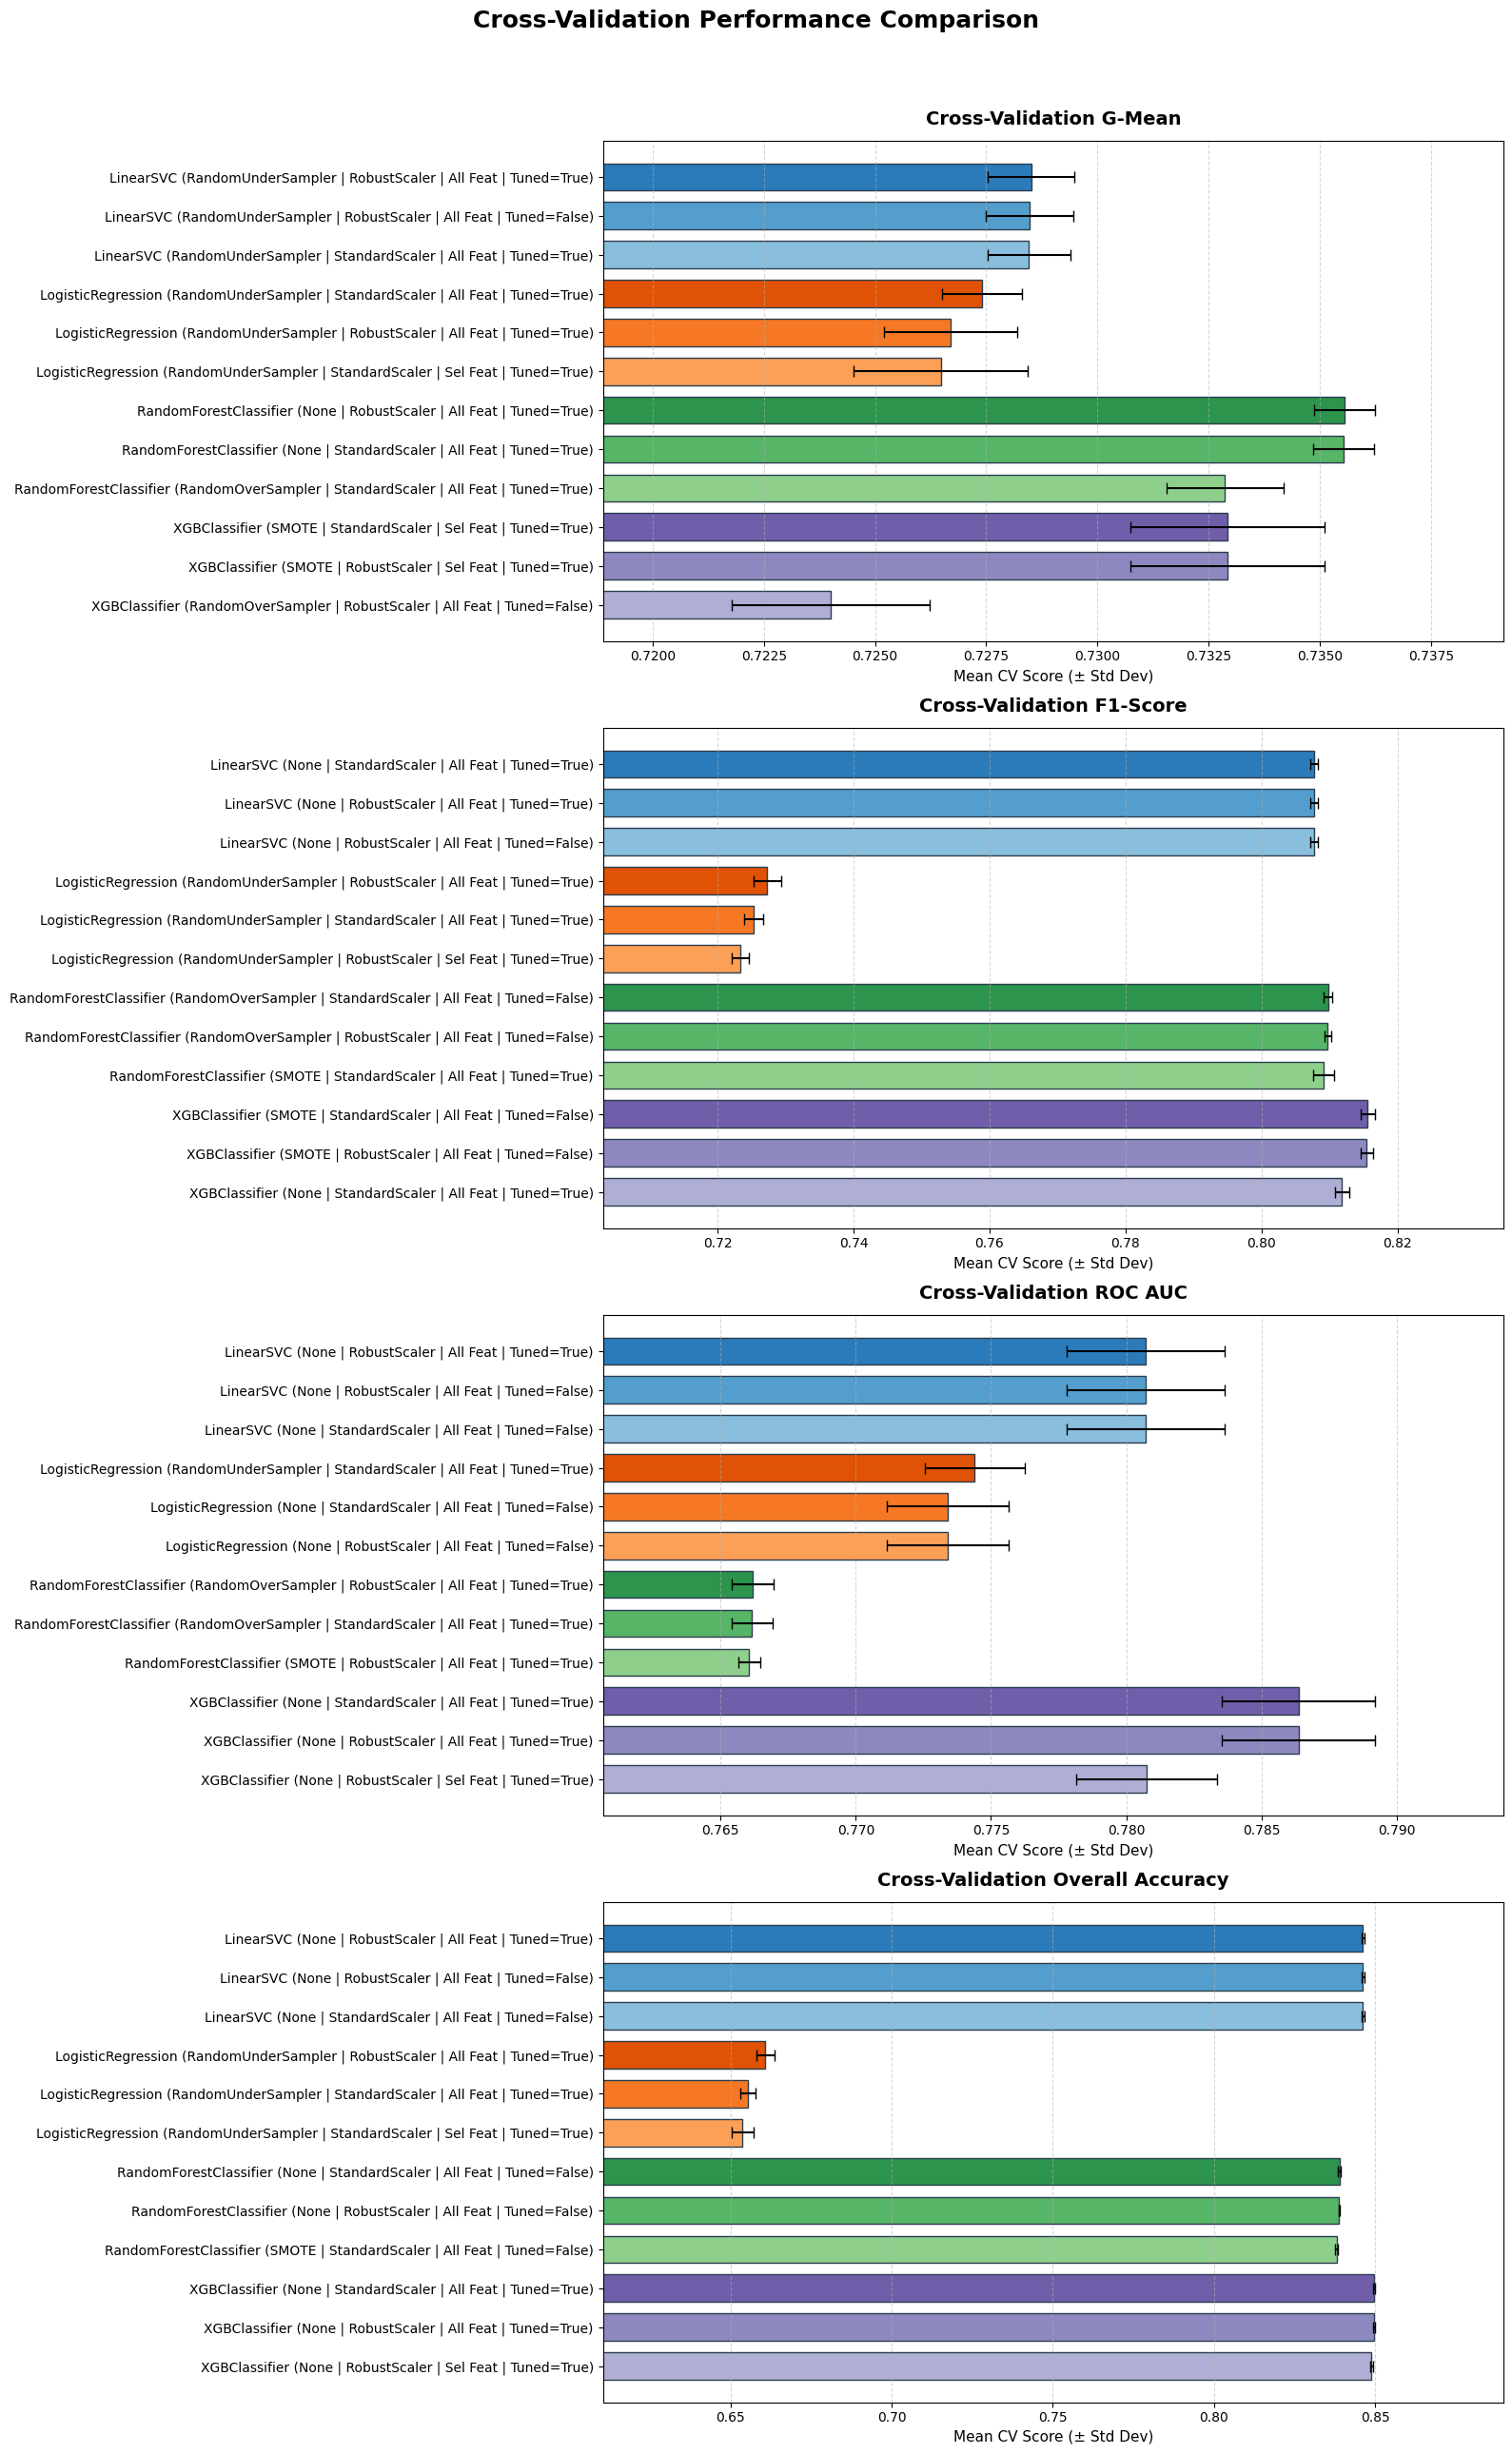

In [117]:
df_results['Config_Label'] = (
    df_results['Model'] + " (" + 
    df_results['Imbalance_Strategy'] + " | " + 
    df_results['Scaler'] + " | " + 
    df_results['All_Features'].map({True: 'All Feat', False: 'Sel Feat'}) + 
    " | Tuned=" + df_results['Tuned'].astype(str) + ")"
)

xgb_shades = sns.color_palette("Blues_r", 6)[1:4]     
lr_shades  = sns.color_palette("Oranges_r", 6)[1:4]   
rf_shades  = sns.color_palette("Greens_r", 6)[1:4]    
svc_shades = sns.color_palette("Purples_r", 6)[1:4]   
grouped_triplets = list(xgb_shades) + list(lr_shades) + list(rf_shades) + list(svc_shades)

metrics_to_plot = {
    "CV_G_Mean": "Cross-Validation G-Mean",
    "CV_F1_Score": "Cross-Validation F1-Score",
    "CV_ROC_AUC": "Cross-Validation ROC AUC",
    "CV_Accuracy": "Cross-Validation Overall Accuracy"
}

var_mapping = {
    "CV_G_Mean": "CV_G_Mean_Var",
    "CV_F1_Score": "CV_F1_Var",
    "CV_ROC_AUC": "CV_ROC_AUC_Var",
    "CV_Accuracy": "CV_Accuracy_Var"
}

fig, axes = plt.subplots(4, 1, figsize=(16, 26))
axes = axes.flatten()

for i, (metric_col, title_name) in enumerate(metrics_to_plot.items()):
    top_per_model = (df_results
                     .sort_values(by=metric_col, ascending=False)
                     .groupby('Model')
                     .head(3))
    
    top_configs = top_per_model.sort_values(by=['Model', metric_col], ascending=[True, False])
    
    var_col = var_mapping[metric_col]
    std_values = np.sqrt(top_configs[var_col].values)
    
    axes[i].barh(
        top_configs['Config_Label'],
        top_configs[metric_col],
        xerr=std_values,
        color=grouped_triplets,
        capsize=4,
        edgecolor='#2c3e50',
        height=0.7
    )
    
    axes[i].invert_yaxis()
    
    axes[i].set_title(title_name, fontsize=14, fontweight='bold', pad=12)
    axes[i].set_xlabel("Mean CV Score (± Std Dev)", fontsize=11)
    axes[i].set_ylabel("") 
    axes[i].grid(axis="x", linestyle="--", alpha=0.5)
    
    min_score = np.min(top_configs[metric_col].values - std_values)
    max_score = np.max(top_configs[metric_col].values + std_values)
    
    padding = (max_score - min_score) * 0.20 if max_score != min_score else 0.05
    axes[i].set_xlim(left=max(0, min_score - padding), right=min(1, max_score + padding))

plt.suptitle("Cross-Validation Performance Comparison", fontsize=18, fontweight='bold', y=0.99)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()